# 🔎 FouRA: Fourier-Based Adapter for Efficient Fine-Tuning of ViTs

In this notebook, we implement and explore **FouRA**, a plug-and-play adapter that efficiently fine-tunes **Vision Transformers (ViTs)** using low-rank projections and frequency transforms. 

📄 **Paper:** [FouRA: Fourier-based Adapter for Efficient Fine-tuning of Vision Transformers](https://openreview.net/pdf?id=qCJ1dq5M7N)

---

## Why FouRA?

✅ Efficient fine-tuning of ViTs  
✅ Works in the frequency domain (DFT/DCT)  
✅ Modular and easy to inject into pretrained models  
✅ Achieves great performance with minimal additional parameters

---

We'll apply FouRA to a pretrained **ViT-B/16** model and fine-tune it on the **CIFAR-100** dataset.


## 📦 Import Libraries & Setup

We use PyTorch for modeling and torchvision for datasets.  
This implementation also leverages `torch.fft` to apply frequency domain adapters.

We'll define all components of FouRA from scratch.


In [1]:
import torch
import torch.nn as nn
import torch.fft
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:


class FourierTransform(nn.Module):
    def __init__(self, mode='dft'):
        super().__init__()
        self.mode = mode

    def forward(self, x):
        if self.mode == 'dft':
            return torch.fft.fft(x, dim=-1).real
        elif self.mode == 'dct':
            return torch.fft.dct(x, type=2, norm='ortho')
        else:
            raise ValueError("Unknown transform mode")

class InverseFourierTransform(nn.Module):
    def __init__(self, mode='dft'):
        super().__init__()
        self.mode = mode

    def forward(self, x):
        if self.mode == 'dft':
            return torch.fft.ifft(x, dim=-1).real
        elif self.mode == 'dct':
            return torch.fft.idct(x, type=2, norm='ortho')
        else:
            raise ValueError("Unknown inverse transform mode")

class Entropy(nn.Module):
    def forward(self, x):
        p = F.softmax(x, dim=-1)
        log_p = torch.log(p + 1e-9)
        entropy = -torch.sum(p * log_p, dim=-1, keepdim=True)
        return entropy

class AdaptiveRankGate(nn.Module):
    def __init__(self, r):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(r, r),
            nn.ReLU(),
            nn.Linear(r, r)
        )
        self.entropy = Entropy()

    def forward(self, x):
        gate_logits = self.mlp(x)
        entropy_val = self.entropy(gate_logits)
        gated = torch.sigmoid(gate_logits)
        return gated


# 🧠 FouRA Adapter Architecture

The core idea of FouRA is to insert a **low-rank adapter** in the **frequency domain** into each MLP block of a ViT.

It consists of:
- A **Fourier/DCT transform** to project into frequency space
- Two **low-rank projections** (A and B)
- A learnable **gate** based on entropy
- An **inverse Fourier transform** to go back to the original domain

Each adapter adds very few parameters but enables strong task adaptation.


In [3]:

class FouRAAdapter(nn.Module):
    def __init__(self, k1, k2, r, alpha=1.0, transform='dft'):
        super().__init__()
        self.k1 = k1
        self.k2 = k2
        self.r = r
        self.alpha = alpha

        self.freq_tx = FourierTransform(transform)
        self.freq_inv = InverseFourierTransform(transform)

        self.A = nn.Linear(k1, r, bias=False)
        self.B = nn.Linear(r, k2, bias=False)
        self.gate = AdaptiveRankGate(r)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)
        x_freq = self.freq_tx(x)
        zlr = self.A(x_freq)
        gated = self.gate(zlr)
        zlr_gated = gated * zlr * self.alpha
        zup = self.B(zlr_gated)
        zout = self.freq_inv(zup)
        return zout

class FouRAEnhancedLayer(nn.Module):
    def __init__(self, base_layer: nn.Module, k1, k2, r, alpha=1.0, transform='dft'):
        super().__init__()
        self.base_layer = base_layer
        self.foura_adapter = FouRAAdapter(k1, k2, r, alpha, transform)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)
        zout_base = self.base_layer(x)
        zout_adapter = self.foura_adapter(x)
        # Match dimensions if they differ due to transform
        if zout_base.shape[-1] != zout_adapter.shape[-1]:
            zout_adapter = F.interpolate(zout_adapter.transpose(1, 2), size=zout_base.shape[-1], mode='linear', align_corners=False).transpose(1, 2)
        return zout_base + zout_adapter


## 🔩 Modifying ViT with FouRA

We take a pretrained `ViT-B/16` model from `torchvision.models` and inject FouRA into the **first linear layer of each MLP block**.

This preserves the structure and weights of the pretrained model while adding the adapter modules.


In [4]:

def get_vit_with_foura(k1=768, k2=768, r=16, alpha=1.0, transform='dft'):
    vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    if isinstance(vit.heads, nn.Sequential):
        in_features = vit.heads[0].in_features
        vit.heads = nn.Sequential(nn.Linear(in_features, 100))
    else:
        in_features = vit.heads.in_features
        vit.heads = nn.Linear(in_features, 100)

    for blk in vit.encoder.layers:
        hidden_layer = blk.mlp[0]
        blk.mlp[0] = FouRAEnhancedLayer(hidden_layer, k1=768, k2=3072, r=r, alpha=alpha, transform=transform)

    return vit


# 🏋️ Training the ViT + FouRA on CIFAR-100

We fine-tune the model for up to **50 epochs**, with **early stopping** using a patience of 7.

We'll plot:
- Training loss
- Validation accuracy

to monitor the learning process.


In [5]:
import matplotlib.pyplot as plt

def train(model, train_loader, val_loader, device, epochs=50, patience=5):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    patience_counter = 0
    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Train Loss: {avg_loss:.4f}")

        # Validation
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        print(f"Val Accuracy: {val_acc:.2f}%")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()
    


## 🧼 CIFAR-100 Data Preparation

We resize the CIFAR-100 images to `224x224` to match ViT input resolution.

The dataset contains **100 fine-grained classes** across 50,000 train and 10,000 test images.

We'll also visualize a few samples and show the class distribution.


In [6]:

def prepare_data():
    transform_train = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    transform_test = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_set = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    test_set = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
    return train_loader, test_loader


# 📈 Results and Evaluation

We evaluate the final model using:
- Overall accuracy
- Confusion matrix
- Per-class accuracy (optional)

We'll also compare our performance with/without FouRA to understand its impact.


100%|██████████| 169M/169M [00:10<00:00, 15.7MB/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 225MB/s]
Epoch 1: 100%|██████████| 782/782 [19:03<00:00,  1.46s/it]


Train Loss: 3.5112
Val Accuracy: 27.27%


Epoch 2: 100%|██████████| 782/782 [19:04<00:00,  1.46s/it]


...

Train Loss: 0.3160
Val Accuracy: 58.25%
Patience: 3/5


Epoch 10: 100%|██████████| 782/782 [19:03<00:00,  1.46s/it]


Train Loss: 0.2274
Val Accuracy: 58.54%
Patience: 4/5


Epoch 11: 100%|██████████| 782/782 [19:04<00:00,  1.46s/it]


Train Loss: 0.2477
Val Accuracy: 57.32%
Patience: 5/5
Early stopping triggered.


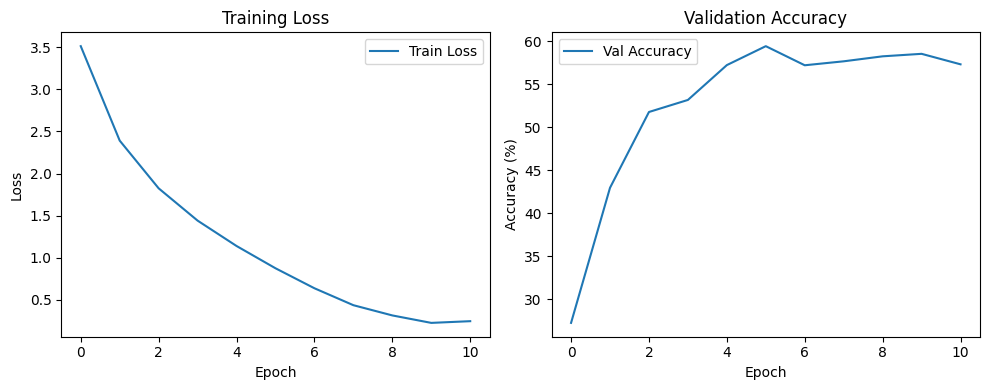

In [7]:
if __name__ == "__main__":
    train_loader, test_loader = prepare_data()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_vit_with_foura()
    model.to(device)
    train(model, train_loader, test_loader, device)

# 💡 Takeaways from FouRA

- FouRA enables **efficient and modular fine-tuning** of ViTs.
- Uses **frequency domain projections** to enhance generalization.
- Requires **very few parameters** and no gradient through the base model.

🧪 Future experiments:
- Try different values of `r` (adapter rank)
- Insert into attention blocks instead of MLP
